In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND4_nterms2/load_band4_data_nterms2.py"

path = band4_nterms2_data_folder_path

B4 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy,
    StokesI_mJy, _, _,
    RA_centre_pix, Dec_centre_pix,
    POLF_debiased
)

band = Band 4 nterms2
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 
Biased


In [4]:
loc = constants.band4_nterms2_data_folder_path

StokesI_dirty_file = loc + "IRS63_Band4_dirty.fits"
StokesI_clean_file = loc + "IRS63_Band4_clean.fits"

In [19]:
StokesI_header_dirty, _, StokesI_dirty_Jy, _ = read_in_file(StokesI_dirty_file)
StokesI_header_clean, _, StokesI_clean_Jy, _ = read_in_file(StokesI_clean_file)

StokesI_dirty_mJy = convert_jy_to_mjy(StokesI_dirty_Jy)
StokesI_clean_mJy = convert_jy_to_mjy(StokesI_clean_Jy)

StokesI_stretched_dirty_mJy, _ = normalize_stokesI_for_cmap(StokesI_dirty_mJy)
StokesI_stretched_clean_mJy, _ = normalize_stokesI_for_cmap(StokesI_clean_mJy)

In [ ]:
results_dirty = get_plotting_parameters(StokesI_header_dirty, StokesI_wcs, 'Band 4 nterms2')


#BMAJ_deg, BMIN_deg, BMAJ_pix, BMIN_pix, BPA_deg_cartesian, reference_length_pix, RA_centre_pix, Dec_centre_pix, xmin, xmax, ymin, ymax

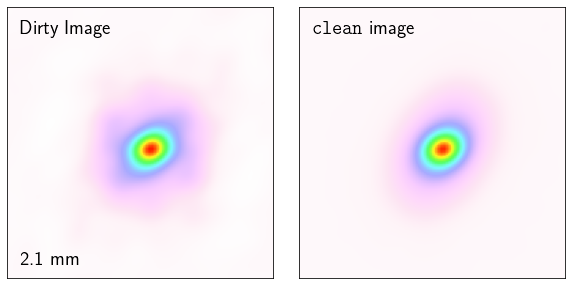

In [26]:
band = B4


fig, ax = plt.subplots(1, 2, figsize=(10, 5),
                       gridspec_kw={'wspace': 0.1},  # Increase wspace for more horizontal space
                       subplot_kw={'projection': band['StokesI_wcs']})

vmin = min(np.nanmin(StokesI_dirty_mJy), np.nanmin(StokesI_clean_mJy))
vmax = max(np.nanmax(StokesI_dirty_mJy), np.nanmax(StokesI_clean_mJy))


im0 = ax[0].imshow(StokesI_dirty_mJy, cmap=soft_colormap_v2, vmin=vmin, vmax=vmax)
im1 = ax[1].imshow(StokesI_clean_mJy, cmap=soft_colormap_v2, vmin=vmin, vmax=vmax)


extra = 0
# --- Shared formatting for all axes ---
for i in range(2):
    # Axis limits and labels
    ax[i].set_xlim(xmin - extra, xmax + extra)
    ax[i].set_ylim(ymin - extra, ymax + extra)

    
    # No x- and y- axis labels
    ax[i].set_xlabel(' ', fontsize = 0)
    ax[i].set_ylabel(' ', fontsize = 0)

    #ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", labelbottom = False, bottom=False, top=False, length=7, labelsize = 0)
    ax[i].tick_params(axis="y", which="major", direction="in", labelleft = False, left=False, right=False, length=7, labelsize = 0)

    # Add the beam
    
    # Beam location
#     beam_x_pos = xmin - 0.1 * (xmin - xmax)
#     beam_y_pos = ymin - 0.1 * (ymin - ymax)
    
#     beam_data = df_beams.iloc[i]
#     beam = Ellipse((beam_x_pos, beam_y_pos), 
#                    width=beam_data['BMAJ_pix'], 
#                    height=beam_data['BMIN_pix'],  
#                    angle=beam_data['BPA_deg_cartesian'], 
#                    edgecolor='black', 
#                    facecolor='none', alpha=1, lw=beam_lw)

#     ax.add_patch(beam)

# Add label on whcih one is clean or not
y_top = 0.9
plt.rcParams['text.usetex'] = True
ax[0].text(0.05, y_top, r'Dirty Image',
           transform=ax[0].transAxes,
           fontsize=20)

ax[1].text(0.05, y_top,  r'\texttt{clean} image',
           transform=ax[1].transAxes,
           fontsize=20)
           #family='monospace')



# Add S/N text
# 565 - 750
# diff = 0.1
# fs = 17.5
# ax[0].text(0.05, y_top - diff, r'S/N $\approx$ 660',
#            transform=ax[0].transAxes,
#            fontsize=fs)

# ax[1].text(0.05, y_top - diff, r'S/N $\approx$ 2655',
#            transform=ax[1].transAxes,
#            fontsize=fs)

ax[0].text(0.05, 0.05, r'2.1 mm',
           transform=ax[0].transAxes,
           fontsize=20)

# ax[1].text(0.05, y_top - diff, r'test',
#            transform=ax[1].transAxes,
#            fontsize=fs)

plt.savefig(image_folder_path + '/WRITEUP/' + "BeforeAndAfterClean_NOTSELFCAL.png", 
            dpi=500, 
            bbox_inches='tight',
               facecolor='white')